# A Simple Statistical Inversion Model Problem

We consider the statistical inversion problem of estimating $(x,y) \in \mathbb{R}^2$ from data $z \in \mathbb{R}$ gathered according the measurement model:
$$
    z = f(x,y) + \eta \qquad \text{ where } \eta \sim N(0, \sigma^2) \text{ and } f: \mathbb{R}^2 \to \mathbb{R}
    \text{ is the forward function. }
    \tag{MM}
$$
Leaving aside the measurement noise $\eta$ we would like to recover $(x,y) = f^{-1}(z)$.  This may be impossible in priciple.  However, if we put a Gaussian prior $\mu_0 \sim N(0, C)$ on $(x,y)$ then the posterior 'bayesian solution' $(x,y)|z$ is the distribution:
$$
    \mu(dx, dy) \propto \exp\left( - \frac{1}{2 \sigma^2} ( f(x,y) - z)^2 
    - \frac{1}{2} <C^{-1}(x,y), (x,y)>\right) dx dy.
    \tag{S}
$$
The experiments below illuminate what these solutions 'look like' for some different examples.

In [2]:
#Some Importing Some External Libraries

#Our MCMC sampliers
%run ../MCMC_Sampliers.ipynb

import warnings
warnings.filterwarnings('ignore')

#Plotting Libraries
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import norm
from numpy import dot, array, transpose, diag
import matplotlib.image as mpimg

#Fun Progress Bar
from tqdm.notebook import tqdm

In [107]:
#Example 1: Statistical Inversion for the function f(x,y) = xy

#Specification of the forward problem (MM)
zdata = 6
sig = 1
fFn = lambda X : X[0]*X[1]
fFnStr = "xy"

#LogLikihood function
nLoglike = lambda X : (2* sig**2)**(-1) *(fFn(X) - zdata )**2

#Specifying the covariance
CovEVs = [3,2]
Tth = 2*np.pi/9

Rot = np.array([
        [np.cos(Tth), -np.sin(Tth)],
        [np.sin(Tth),  np.cos(Tth)]
    ])
Diag = np.diag(CovEVs)

prCov = Rot.T @ Diag @ Rot


In [108]:
#Generate Data Using MpCN

NumRuns =  25 #of total runs
NumSamps = 1000 #samples per run


#Specifying File Location to Save Data 

#subdirectory from current location of python notebook (this should be created manually)
FileNmBase= "Data/Simple_Inversion_Toy/"

paraStr = "_fFn_"+ fFnStr+ "_z_" + str(zdata)+ "_sig_" + str(sig) + "_CovEVs_" + str(CovEVs) + "_CovRot_" + str(Tth)
histFileNm = FileNmBase + "HIST" + paraStr + ".png"
csvFileNm = FileNmBase + "DATA" + paraStr + ".csv"


rho = .6
pSmp = 100

print("  ")
print("MpCN Run")
print("Total samples generated: " + str(NumRuns*NumSamps))

print("rho Value: " + str(rho))
print("p Value: " + str(pSmp))
print("  ")


badtryNm = 0


#Make mpCN Run Saving to .csv ensuring NAN errors do not stop the process

q0 = np.random.normal(0,1,2)
for curRnInx in tqdm(range(0,NumRuns)):
    try:
        cursamps = MpCN(q0,2,prCov,rho,nLoglike,pSmp,NumSamps +1)
        q0 = cursamps.pop()
        writeCSV(csvFileNm,cursamps)
    except OverflowError:
        badtryNm = badtryNm +1

print("Number of failed runs: " + str(badtryNm))
print("Percentage of Failure: " + str(badtryNm/NumRuns))

  
MpCN Run
Total samples generated: 25000
rho Value: 0.6
p Value: 100
  


  0%|          | 0/25 [00:00<?, ?it/s]

Number of failed runs: 0
Percentage of Failure: 0.0


Number of MpCN Samples Now Available: 24999


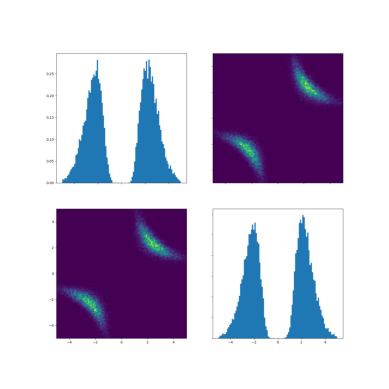

In [109]:
#Make Histogram

mpCNsampTr = readCSV(csvFileNm)
samLenmpCN = len(mpCNsampTr)
print("Number of MpCN Samples Now Available: " + str(samLenmpCN))

#Dimensions For Histogram Plot
R = 5
dr = .1

makeHistGrid(R, dr, mpCNsampTr, 2,histFileNm, True)

img = mpimg.imread(histFileNm)
plt.imshow(img)
plt.axis('off')  # Turn off the axes
plt.show()

In [122]:
#Example 2: Statistical Inversion for the function f(x,y) = x/(1+y^2)

#Specification of the forward problem (MM)
zdata = .1
sig = .5
fFn = lambda X : X[0]*(1+X[1]**2)**(-1)
fFnStr = "x(1+y^2)^-1"

#LogLikihood function
nLoglike = lambda X : (2* sig**2)**(-1) *(fFn(X) - zdata )**2

#Specifying the covariance
CovEVs = [.5,4]
Tth = 2*np.pi/6

Rot = np.array([
        [np.cos(Tth), -np.sin(Tth)],
        [np.sin(Tth),  np.cos(Tth)]
    ])
Diag = np.diag(CovEVs)

prCov = Rot.T @ Diag @ Rot
print(prCov)

[[3.125      1.51554446]
 [1.51554446 1.375     ]]


In [126]:
#Generate Data Using MpCN

NumRuns =  75 #of total runs
NumSamps = 1000 #samples per run


#Specifying File Location to Save Data 

#subdirectory from current location of python notebook (this should be created manually)
FileNmBase= "Data/Simple_Inversion_Toy/"

paraStr = "_fFn_"+ fFnStr+ "_z_" + str(zdata)+ "_sig_" + str(sig) + "_CovEVs_" + str(CovEVs) + "_CovRot_" + str(Tth)
histFileNm = FileNmBase + "HIST" + paraStr + ".png"
csvFileNm = FileNmBase + "DATA" + paraStr + ".csv"


rho = .6
pSmp = 100

print("  ")
print("MpCN Run")
print("Total samples generated: " + str(NumRuns*NumSamps))

print("rho Value: " + str(rho))
print("p Value: " + str(pSmp))
print("  ")


badtryNm = 0


#Make mpCN Run Saving to .csv ensuring NAN errors do not stop the process

q0 = np.random.normal(0,1,2)
for curRnInx in tqdm(range(0,NumRuns)):
    try:
        cursamps = MpCN(q0,2,prCov,rho,nLoglike,pSmp,NumSamps +1)
        q0 = cursamps.pop()
        writeCSV(csvFileNm,cursamps)
    except OverflowError:
        badtryNm = badtryNm +1

print("Number of failed runs: " + str(badtryNm))
print("Percentage of Failure: " + str(badtryNm/NumRuns))

  
MpCN Run
Total samples generated: 75000
rho Value: 0.6
p Value: 100
  


  0%|          | 0/75 [00:00<?, ?it/s]

Number of failed runs: 0
Percentage of Failure: 0.0


Number of MpCN Samples Now Available: 99999


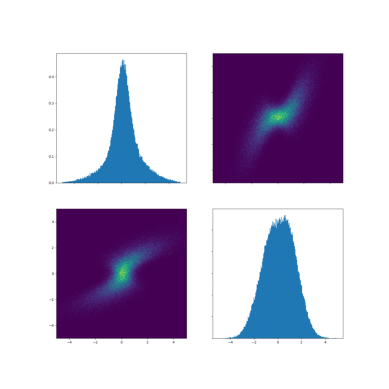

In [129]:
#Make Histogram

mpCNsampTr = readCSV(csvFileNm)
samLenmpCN = len(mpCNsampTr)
print("Number of MpCN Samples Now Available: " + str(samLenmpCN))

#Dimensions For Histogram Plot
R = 5
dr = .05

makeHistGrid(R, dr, mpCNsampTr, 2,histFileNm, True)

img = mpimg.imread(histFileNm)
plt.imshow(img)
plt.axis('off')  # Turn off the axes
plt.show()

In [3]:
#Example 3: Statistical Inversion for f(x,y) = xy^3

#Specification of the forward problem (MM)
zdata = 4
sig = 1.5
fFn = lambda X : X[0]*X[1]**3
fFnStr = "xy^3"

#LogLikihood function
nLoglike = lambda X : (2* sig**2)**(-1) *(fFn(X) - zdata )**2

#Specifying the covariance
CovEVs = [.5,4]
Tth = 2*np.pi/3

Rot = np.array([
        [np.cos(Tth), -np.sin(Tth)],
        [np.sin(Tth),  np.cos(Tth)]
    ])
Diag = np.diag(CovEVs)

prCov = Rot.T @ Diag @ Rot
print(prCov)

[[ 3.125      -1.51554446]
 [-1.51554446  1.375     ]]


In [4]:
#Generate Data Using MpCN

NumRuns =  75 #of total runs
NumSamps = 1000 #samples per run


#Specifying File Location to Save Data 

#subdirectory from current location of python notebook (this should be created manually)
FileNmBase= "Data/Simple_Inversion_Toy/"

paraStr = "_fFn_"+ fFnStr+ "_z_" + str(zdata)+ "_sig_" + str(sig) + "_CovEVs_" + str(CovEVs) + "_CovRot_" + str(Tth)
histFileNm = FileNmBase + "HIST" + paraStr + ".png"
csvFileNm = FileNmBase + "DATA" + paraStr + ".csv"


rho = .6
pSmp = 100

print("  ")
print("MpCN Run")
print("Total samples generated: " + str(NumRuns*NumSamps))

print("rho Value: " + str(rho))
print("p Value: " + str(pSmp))
print("  ")


badtryNm = 0


#Make mpCN Run Saving to .csv ensuring NAN errors do not stop the process

q0 = np.random.normal(0,1,2)
for curRnInx in tqdm(range(0,NumRuns)):
    try:
        cursamps = MpCN(q0,2,prCov,rho,nLoglike,pSmp,NumSamps +1)
        q0 = cursamps.pop()
        writeCSV(csvFileNm,cursamps)
    except OverflowError:
        badtryNm = badtryNm +1

print("Number of failed runs: " + str(badtryNm))
print("Percentage of Failure: " + str(badtryNm/NumRuns))

  
MpCN Run
Total samples generated: 75000
rho Value: 0.6
p Value: 100
  


  0%|          | 0/75 [00:00<?, ?it/s]

Number of failed runs: 0
Percentage of Failure: 0.0


Number of MpCN Samples Now Available: 99999


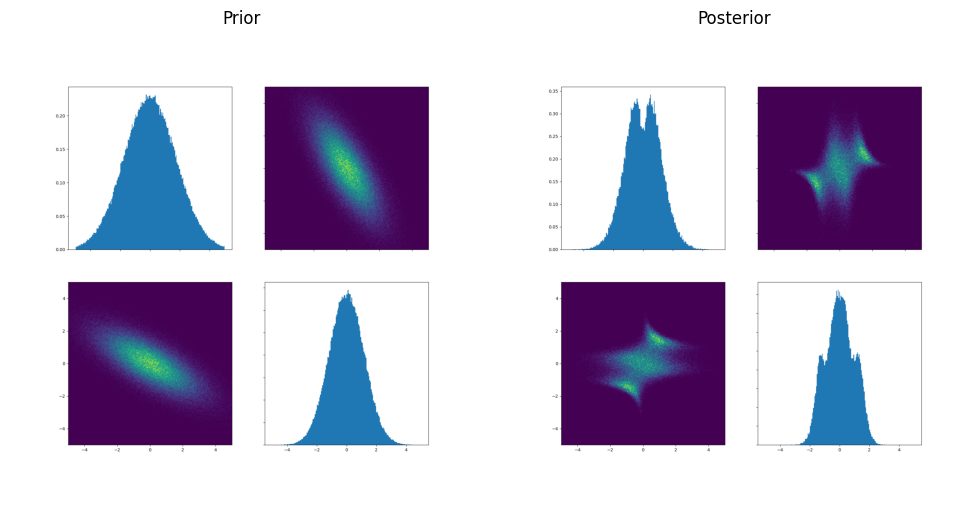

Posterior Mean:  [0.00764824 0.00940349]
Posterior Covariance: [[1.3399456  0.4491369 ]
 [0.4491369  0.94486135]]
Log Likelihood of the Bayes Estimator: 3.555555544249629


In [32]:
#Statistics for Example 3

mpCNsampTr = readCSV(csvFileNm)
samLenmpCN = len(mpCNsampTr)
print("Number of MpCN Samples Now Available: " + str(samLenmpCN))

#Dimensions For Histogram Plot
R = 5
dr = .05

makeHistGrid(R, dr, mpCNsampTr, 2,histFileNm, True)


#Generate the prior
FileNmBase= "Data/Simple_Inversion_Toy/"
paraStr = "_PRIOR_fFn_"+ fFnStr+ "_CovEVs_" + str(CovEVs) + "_CovRot_" + str(Tth)
histFileNmPR = FileNmBase + "HIST" + paraStr + ".png"

L = 250000
PR_array = np.random.multivariate_normal(np.zeros(2),prCov, L)
makeHistGrid(R, dr, PR_array.tolist(), 2,histFileNmPR, True)



# Load images for the prior and posterior
img1 = mpimg.imread(histFileNmPR)
img2 = mpimg.imread(histFileNm)

# Create a figure and axes with two subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Display the first image
axes[0].imshow(img1)
axes[0].axis('off')  # Hide the axis
axes[0].set_title("Prior")

# Display the second image
axes[1].imshow(img2)
axes[1].axis('off')
axes[1].set_title("Posterior")

plt.tight_layout()
plt.show()

#Compute the Bayes estimator
mean_mpCNsampTr = np.mean(mpCNsampTr, axis=0)
print("Posterior Mean:  " + str(mean_mpCNsampTr))

#Compute the Posterior Covariance
n = mpCNsampTr.shape[0]
mpCNsampTr_centered = mpCNsampTr - mean_mpCNsampTr
postCov = (1.0 / (n - 1)) * (mpCNsampTr_centered.T @ mpCNsampTr_centered)
print("Posterior Covariance: " + str(postCov))

#Compute the negative loglikihood of the posterior mean

print("Log Likelihood of the Bayes Estimator: " + str(nLoglike(mean_mpCNsampTr)))


In [7]:
#Example 3: Statistical Inversion for f(x,y) = (x - x_0)^2/a^2 + (y-y_0)^2/b^2

#Specification of the forward problem (MM)
zdata = 1
sig = .05
a0 = 1
b0 = 3
asqI = a0**(-2) 
bsqI = b0 **(-2)
x0 = 1
y0 = 0
fFn = lambda X : asqI*(X[0] - x0)**2  + bsqI*(X[1]-y0)**2
fFnStr = "(x - " + str(x0) + ")^2*" + str(a0) + "^(-2) + (y - " + str(x0) + ")^2*" + str(b0) + "^(-2)"
print(fFnStr)

#LogLikihood function
nLoglike = lambda X : (2* sig**2)**(-1) *(fFn(X) - zdata )**2

#Specifying the covariance
CovEVs = [.5,2]
Tth = 2*np.pi/3

Rot = np.array([
        [np.cos(Tth), -np.sin(Tth)],
        [np.sin(Tth),  np.cos(Tth)]
    ])
Diag = np.diag(CovEVs)

prCov = Rot.T @ Diag @ Rot
#print(prCov)

(x - 1)^2*1^(-2) + (y - 1)^2*3^(-2)


In [47]:
#Generate Data Using MpCN

NumRuns =  100 #of total runs
NumSamps = 10000 #samples per run


#Specifying File Location to Save Data 

#subdirectory from current location of python notebook (this should be created manually)
FileNmBase= "Data/Simple_Inversion_Toy/"

paraStr = "_fFn_"+ fFnStr+ "_z_" + str(zdata)+ "_sig_" + str(sig) + "_CovEVs_" + str(CovEVs) + "_CovRot_" + str(Tth)
#paraStr = "_z_" + str(zdata)+ "_sig_" + str(sig) + "_CovEVs_" + str(CovEVs) + "_CovRot_" + str(Tth)
histFileNm = FileNmBase + "HIST" + paraStr + ".png"
csvFileNm = FileNmBase + "DATA" + paraStr + ".csv"
print(csvFileNm)


rho = .1
pSmp = 100

print("  ")
print("MpCN Run")
print("Total samples generated: " + str(NumRuns*NumSamps))

print("rho Value: " + str(rho))
print("p Value: " + str(pSmp))
print("  ")


badtryNm = 0


#Make mpCN Run Saving to .csv ensuring NAN errors do not stop the process

q0 = np.random.normal(0,1,2)
for curRnInx in tqdm(range(0,NumRuns)):
    try:
        cursamps = MpCN(q0,2,prCov,rho,nLoglike,pSmp,NumSamps +1)
        q0 = cursamps[NumSamps+1]
        writeCSV(csvFileNm,cursamps)
    except OverflowError:
        badtryNm = badtryNm +1

print("Number of failed runs: " + str(badtryNm))
print("Percentage of Failure: " + str(badtryNm/NumRuns))

Data/Simple_Inversion_Toy/DATA_fFn_(x - 1)^2*1^(-2) + (y - 1)^2*3^(-2)_z_1_sig_0.05_CovEVs_[0.5, 2]_CovRot_2.0943951023931953.csv
  
MpCN Run
Total samples generated: 1000000
rho Value: 0.1
p Value: 100
  


  0%|          | 0/100 [00:00<?, ?it/s]

Number of failed runs: 0
Percentage of Failure: 0.0


Number of MpCN Samples Now Available: 1010201


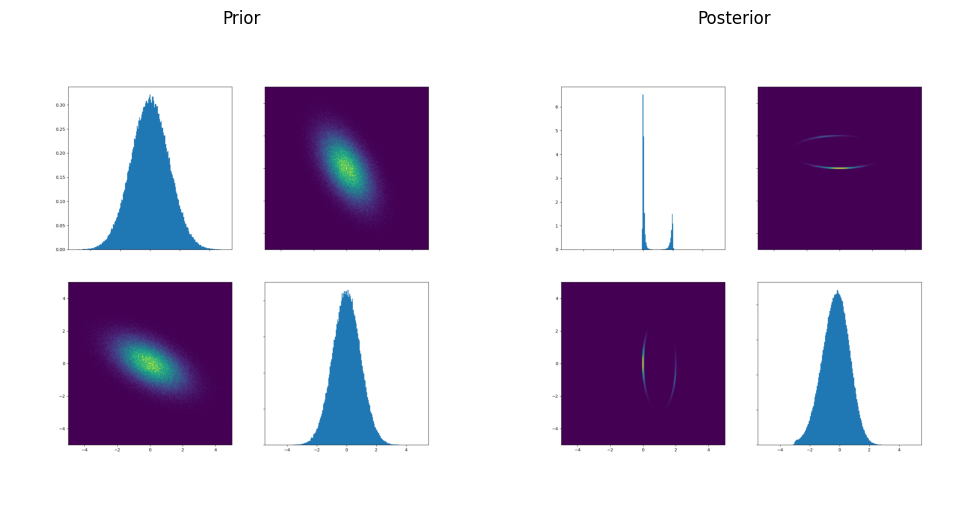

Posterior Mean:  [ 0.49906255 -0.26276678]
Posterior Covariance: [[ 0.64874594 -0.27486419]
 [-0.27486419  0.81730696]]
Log Likelihood of the Bayes Estimator: 109.93178234175792


In [49]:
#Statistics for Example 4

mpCNsampTr = readCSV(csvFileNm)
samLenmpCN = len(mpCNsampTr)
print("Number of MpCN Samples Now Available: " + str(samLenmpCN))

#Dimensions For Histogram Plot
R = 5
dr = .05

makeHistGrid(R, dr, mpCNsampTr, 2,histFileNm, True)


#Generate the prior
FileNmBase= "Data/Simple_Inversion_Toy/"
paraStr = "_PRIOR_fFn_"+ fFnStr+ "_CovEVs_" + str(CovEVs) + "_CovRot_" + str(Tth)
histFileNmPR = FileNmBase + "HIST" + paraStr + ".png"

L = 250000
PR_array = np.random.multivariate_normal(np.zeros(2),prCov, L)
makeHistGrid(R, dr, PR_array.tolist(), 2,histFileNmPR, True)



# Load images for the prior and posterior
img1 = mpimg.imread(histFileNmPR)
img2 = mpimg.imread(histFileNm)

# Create a figure and axes with two subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Display the first image
axes[0].imshow(img1)
axes[0].axis('off')  # Hide the axis
axes[0].set_title("Prior")

# Display the second image
axes[1].imshow(img2)
axes[1].axis('off')
axes[1].set_title("Posterior")

plt.tight_layout()
plt.show()

#Compute the Bayes estimator
mean_mpCNsampTr = np.mean(mpCNsampTr, axis=0)
print("Posterior Mean:  " + str(mean_mpCNsampTr))

#Compute the Posterior Covariance
n = mpCNsampTr.shape[0]
mpCNsampTr_centered = mpCNsampTr - mean_mpCNsampTr
postCov = (1.0 / (n - 1)) * (mpCNsampTr_centered.T @ mpCNsampTr_centered)
print("Posterior Covariance: " + str(postCov))

#Compute the negative loglikihood of the posterior mean

print("Log Likelihood of the Bayes Estimator: " + str(nLoglike(mean_mpCNsampTr)))


  
locMpCN Run
Total samples generated: 10000000
rho Value: 0.995
p Value: 100
  
Rejection rate:
0.22685773142268578


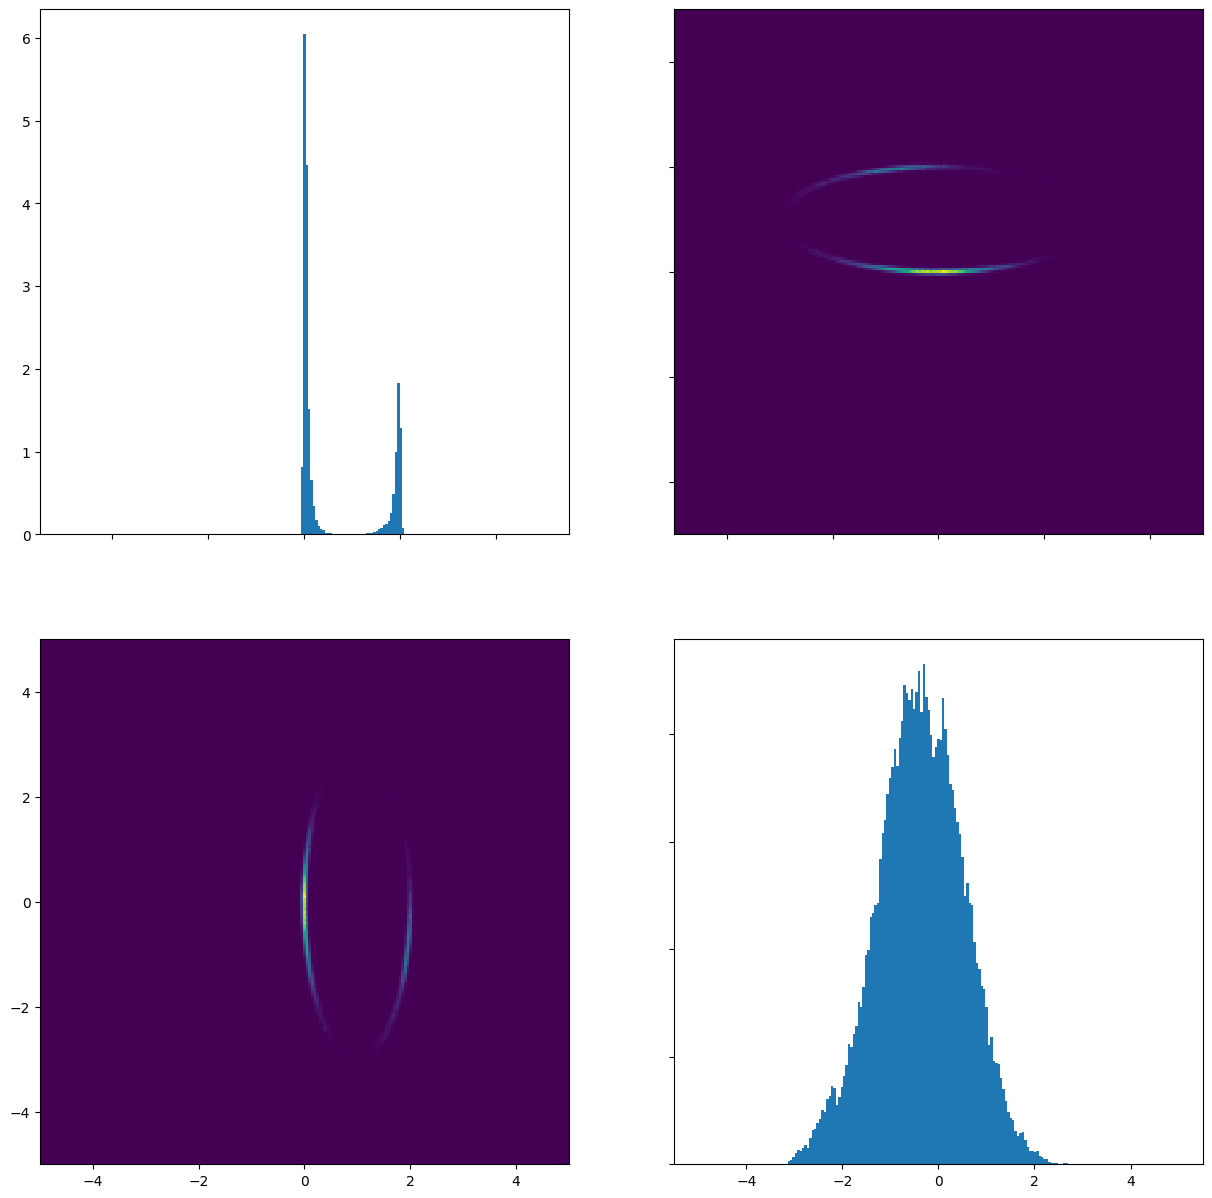

In [50]:
#Generate Data Using MpCN

#NumRuns =  1 #of total runs
NumSamps = 100000 #samples per run


#Specifying File Location to Save Data 

#subdirectory from current location of python notebook (this should be created manually)
FileNmBase= "Data/Simple_Inversion_Toy/"

rho = .995
pSmp = 100

paraStr = "_fFn_"+ fFnStr+ "_z_" + str(zdata)+ "_sig_" + str(sig) + "_CovEVs_" + str(CovEVs) + "_CovRot_" + str(Tth)
#paraStr = "_z_" + str(zdata)+ "_sig_" + str(sig) + "_CovEVs_" + str(CovEVs) + "_CovRot_" + str(Tth)
histFileNm = FileNmBase + "rho_" + str(rho) + "_p_" + str(pSmp) +"_N_" + str(NumSamps)+ "_locmpcn_HIST" + paraStr + ".png"
csvFileNm = FileNmBase + "rho_" + str(rho) + "_p_" + str(pSmp) + "_N_" + str(NumSamps)+"_locmpcn_DATA" + paraStr + ".csv"





print("  ")
print("locMpCN Run")
print("Total samples generated: " + str(NumRuns*NumSamps))

print("rho Value: " + str(rho))
print("p Value: " + str(pSmp))
print("  ")


badtryNm = 0


#Make mpCN Run Saving to .csv ensuring NAN errors do not stop the process

q0 = np.random.normal(0,1,2)
#for curRnInx in tqdm(range(0,NumRuns)):
#    try:        
#        q0 = cursamps[NumSamps+1]
#        writeCSV(csvFileNm,cursamps)
#    except OverflowError:
#        badtryNm = badtryNm +1

#print("Number of failed runs: " + str(badtryNm))
#print("Percentage of Failure: " + str(badtryNm/NumRuns))

#mpCNsampTr = readCSV(csvFileNm)
#samLenmpCN = len(mpCNsampTr)
#print("Number of MpCN Samples Now Available: " + str(samLenmpCN))

cursamps = locMpCNMTM(q0,2,prCov,rho,nLoglike,pSmp,NumSamps +1,True)

#Dimensions For Histogram Plot
R = 5
dr = .05

makeHistGrid(R, dr, cursamps, 2,histFileNm, False)